# NAO verif

In [1]:
import os
import sys
import yaml
import copy

import numpy as np
import pandas as pd
import xarray as xr

In [2]:
sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [3]:
import cmaps
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
%matplotlib inline

In [4]:
# from eofs.xarray import Eof
from scipy.stats import pearsonr, t as student_t

In [5]:
# -----------------------------
# helper functions
# -----------------------------
def lag1_autocorr(x):
    """Lag-1 autocorrelation for a 1D numpy array."""
    x = np.asarray(x, dtype=float)
    if x.size < 3:
        return np.nan
    x0 = x[:-1]
    x1 = x[1:]
    mask = np.isfinite(x0) & np.isfinite(x1)
    if mask.sum() < 2:
        return np.nan
    return np.corrcoef(x0[mask], x1[mask])[0, 1]


def effective_sample_size(x, y):
    """
    Bretherton-style effective sample size using lag-1 autocorrelation.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    n = x.size

    if n < 3:
        return np.nan

    r1_x = lag1_autocorr(x)
    r1_y = lag1_autocorr(y)

    if not np.isfinite(r1_x) or not np.isfinite(r1_y):
        return float(n)

    neff = n * (1.0 - r1_x * r1_y) / (1.0 + r1_x * r1_y)

    # keep in a sensible range
    neff = max(3.0, min(float(n), float(neff)))
    return neff


def corr_pvalue_from_neff(r, neff):
    """
    Two-sided p-value for Pearson r using effective sample size.
    """
    if not np.isfinite(r) or not np.isfinite(neff) or neff <= 2:
        return np.nan

    # protect against |r|=1
    r = np.clip(r, -0.999999999, 0.999999999)

    tval = r * np.sqrt((neff - 2.0) / (1.0 - r**2))
    pval = 2.0 * student_t.sf(np.abs(tval), df=neff - 2.0)
    return float(pval)

In [6]:
# -----------------------------
# load data
# -----------------------------
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS/NAO_ERA5_REOF.zarr'
ds_ERA5_year = xr.open_zarr(fn).load()

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS/NAO_mon_ERA5_REOF.zarr'
ds_ERA5_mon = xr.open_zarr(fn).load()

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS/NAO_CESM_REOF.zarr'
ds_CESM_year = xr.open_zarr(fn).load()

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS/NAO_mon_ERA5_REOF.zarr'
ds_CESM_mon = xr.open_zarr(fn).load()

def verify_pair_1d(da_model, da_obs, dim='init_year'):
    """
    Compute verification metrics for two aligned 1D time series.
    Returns a dict of scalar metrics.
    """
    da_model, da_obs = xr.align(da_model, da_obs, join="inner")

    valid = np.isfinite(da_model) & np.isfinite(da_obs)
    da_model = da_model.where(valid, drop=True)
    da_obs = da_obs.where(valid, drop=True)

    n = int(da_model.sizes.get(dim, 0))
    if n < 2:
        return {
            "acc": np.nan,
            "acc_p_value": np.nan,
            "acc_p_value_neff": np.nan,
            "n_eff": np.nan,
            "rmse": np.nan,
            "crmse": np.nan,
            "mae": np.nan,
            "mse": np.nan,
            "bias": np.nan,
            "mean_model": np.nan,
            "mean_obs": np.nan,
            "std_model": np.nan,
            "std_obs": np.nan,
            "std_ratio": np.nan,
            "n_samples": n,
        }

    x = da_model.values.astype(float)
    y = da_obs.values.astype(float)

    # ACC and standard p-value
    if n >= 3:
        r, p = pearsonr(x, y)
    else:
        r, p = np.nan, np.nan

    # effective-sample-size-adjusted p-value
    neff = effective_sample_size(x, y)
    p_neff = corr_pvalue_from_neff(r, neff)

    err = x - y

    rmse = np.sqrt(np.mean(err**2))
    mse = np.mean(err**2)
    mae = np.mean(np.abs(err))
    bias = np.mean(err)

    xm = np.mean(x)
    ym = np.mean(y)
    xstd = np.std(x, ddof=0)
    ystd = np.std(y, ddof=0)

    # centered RMSE
    crmse = np.sqrt(np.mean(((x - xm) - (y - ym))**2))

    std_ratio = xstd / ystd if np.isfinite(ystd) and ystd != 0 else np.nan

    return {
        "acc": float(r),
        "acc_p_value": float(p) if np.isfinite(p) else np.nan,
        "acc_p_value_neff": float(p_neff) if np.isfinite(p_neff) else np.nan,
        "n_eff": float(neff) if np.isfinite(neff) else np.nan,
        "rmse": float(rmse),
        "crmse": float(crmse),
        "mae": float(mae),
        "mse": float(mse),
        "bias": float(bias),
        "mean_model": float(xm),
        "mean_obs": float(ym),
        "std_model": float(xstd),
        "std_obs": float(ystd),
        "std_ratio": float(std_ratio) if np.isfinite(std_ratio) else np.nan,
        "n_samples": int(n),
    }


def metrics_to_dataset(metrics_dict, suffix):
    """
    Convert metrics dict to xr.Dataset with suffixed variable names.
    """
    return xr.Dataset({f"{k}_{suffix}": xr.DataArray(v) for k, v in metrics_dict.items()})


# -----------------------------
# main verification loop
# -----------------------------
lead_coord = (
    ds_CESM_year["lead_year"].values
    if "lead_year" in ds_CESM_year.coords
    else np.arange(10)
)

list_out = []

for ilead in range(10):
    # shift init_year -> valid year for this lead
    ds_CESM_slice = ds_CESM_year.isel(lead_year=ilead).assign_coords(
        init_year=ds_CESM_year.isel(lead_year=ilead)["init_year"] + ilead + 1
    )

    # --- DJF ---
    met_djf = verify_pair_1d(
        ds_CESM_slice["nao_djf_eof"],
        ds_ERA5_year["nao_djf_eof"],
        dim="init_year",
    )

    # --- ANN ---
    met_ann = verify_pair_1d(
        ds_CESM_slice["nao_ann_eof"],
        ds_ERA5_year["nao_ann_eof"],
        dim="init_year",
    )

    ds_lead = xr.merge([
        metrics_to_dataset(met_djf, "djf"),
        metrics_to_dataset(met_ann, "ann"),
    ])

    ds_lead = ds_lead.expand_dims(
        lead_year=[lead_coord[ilead]]
    )

    list_out.append(ds_lead)

ds_verify_nao = xr.concat(list_out, dim="lead_year")

print(ds_verify_nao)

<xarray.Dataset> Size: 2kB
Dimensions:               (lead_year: 10)
Coordinates:
  * lead_year             (lead_year) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables: (12/30)
    acc_djf               (lead_year) float64 80B 0.137 0.1197 ... -0.009411
    acc_p_value_djf       (lead_year) float64 80B 0.2885 0.3541 ... 0.145 0.9441
    acc_p_value_neff_djf  (lead_year) float64 80B 0.3102 0.3774 ... 0.1894 0.949
    n_eff_djf             (lead_year) float64 80B 56.88 56.48 ... 48.33 48.74
    rmse_djf              (lead_year) float64 80B 1.207 1.124 ... 1.127 1.217
    crmse_djf             (lead_year) float64 80B 1.207 1.123 ... 1.125 1.216
    ...                    ...
    mean_model_ann        (lead_year) float64 80B -1.477e-17 ... 0.04891
    mean_obs_ann          (lead_year) float64 80B 0.02196 0.007979 ... 0.02982
    std_model_ann         (lead_year) float64 80B 0.3945 0.3723 ... 0.4101
    std_obs_ann           (lead_year) float64 80B 0.3711 0.3773 ... 0.3788
    std_ratio_ann   

In [7]:
list(ds_verify_nao.keys())

['acc_djf',
 'acc_p_value_djf',
 'acc_p_value_neff_djf',
 'n_eff_djf',
 'rmse_djf',
 'crmse_djf',
 'mae_djf',
 'mse_djf',
 'bias_djf',
 'mean_model_djf',
 'mean_obs_djf',
 'std_model_djf',
 'std_obs_djf',
 'std_ratio_djf',
 'n_samples_djf',
 'acc_ann',
 'acc_p_value_ann',
 'acc_p_value_neff_ann',
 'n_eff_ann',
 'rmse_ann',
 'crmse_ann',
 'mae_ann',
 'mse_ann',
 'bias_ann',
 'mean_model_ann',
 'mean_obs_ann',
 'std_model_ann',
 'std_obs_ann',
 'std_ratio_ann',
 'n_samples_ann']

In [8]:
ds_ERA5_mon['NAO monthly'][-10:].values

array([ 0.44844852,  0.00126812,  0.23008054,  0.95068877,  0.61986519,
        0.21764409, -0.40183069, -0.78447601, -1.24424872,  0.4711378 ])

In [9]:
cmap = gu.precip_cmap(return_rgb=False, land_map=False)

my_colors = gu.ksha_color_set_summon(color_set=0)
cyan = np.array([0.4, 0.8, 1, 1])
blue = my_colors['blue']
red = my_colors['red']
orange = my_colors['orange']

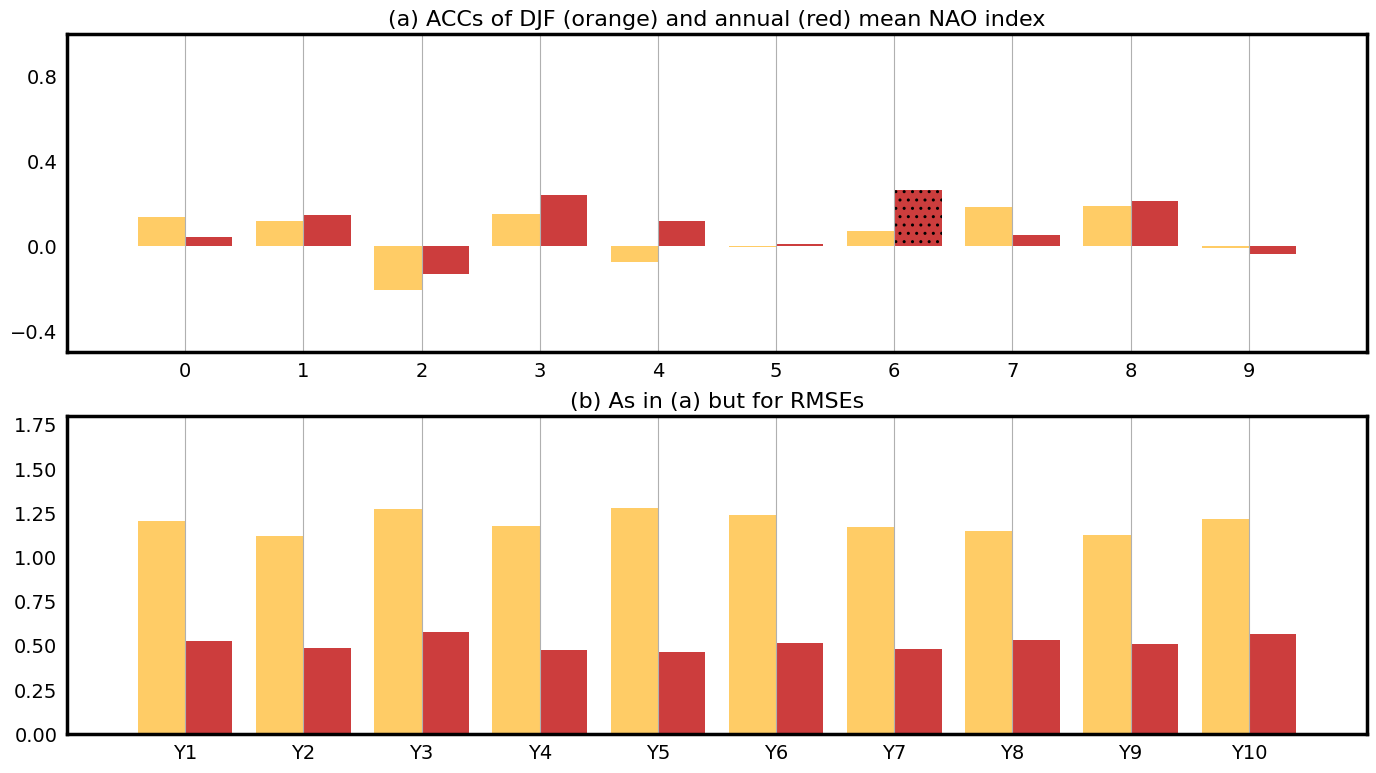

In [11]:
fig = plt.figure(figsize=(13, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1], width_ratios=[1,])

AX_lines = []
AX_lines.append(plt.subplot(gs[0, :]))
AX_lines.append(plt.subplot(gs[1, :]))

fake_x = np.arange(10)

for ax in AX_lines:
    ax = gu.ax_decorate_box(ax)
    ax.tick_params(labelbottom=True)

    
    ax.set_xlim(-1, fake_x[-1] + 1)
    ax.set_xticks(fake_x)
    ax.tick_params(labelleft=True)
    ax.grid(axis='x')

AX_lines[0].tick_params(labelleft=True)
AX_lines[0].set_ylim([-0.5, 1])
AX_lines[0].set_yticks([-0.4, 0, 0.4, 0.8])
AX_lines[0].set_title('(a) ACCs of DJF (orange) and annual (red) mean NAO index', fontsize=16)
AX_lines[1].set_title('(b) As in (a) but for RMSEs', fontsize=16)
AX_lines[1].set_xticklabels(['Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6', 'Y7', 'Y8', 'Y9', 'Y10'])
AX_lines[1].set_ylim([0, 1.8])

plt.subplots_adjust(0, 0, 1, 1, hspace=0.2, wspace=0.1)

width = 0.40
x1 = fake_x - width/2   # left bars
x2 = fake_x + width/2   # right bars

ax = AX_lines[0]

bars1 = ax.bar(x1, ds_verify_nao['acc_djf'], width=width, color=orange, edgecolor="none")
mask_pval = ds_verify_nao['acc_p_value_djf'] < 0.05
for rect, m in zip(bars1, mask_pval):
    if m:
        rect.set_hatch("..")
        rect.set_edgecolor("k")
        rect.set_linewidth(0.0)

bars2 = ax.bar(x2, ds_verify_nao['acc_ann'], width=width, color=red, edgecolor="none")
mask_pval = ds_verify_nao['acc_p_value_ann'] < 0.05
for rect, m in zip(bars2, mask_pval):
    if m:
        rect.set_hatch("..")
        rect.set_edgecolor("k")
        rect.set_linewidth(0.0)


ax = AX_lines[1]

bars1 = ax.bar(x1, ds_verify_nao['rmse_djf'], width=width, color=orange, edgecolor="none")
bars2 = ax.bar(x2, ds_verify_nao['rmse_ann'], width=width, color=red, edgecolor="none")

In [12]:
fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS/NAO_ERA5_REOF.zarr'
ds_ERA5_year = xr.open_zarr(fn).load()

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS/NAO_mon_ERA5_REOF.zarr'
ds_ERA5_mon = xr.open_zarr(fn).load()

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS/NAO_CESM_REOF.zarr'
ds_CESM_year = xr.open_zarr(fn).load()

fn = '/glade/derecho/scratch/ksha/EPRI_data/METRICS/NAO_mon_ERA5_REOF.zarr'
ds_CESM_mon = xr.open_zarr(fn).load()


list_ACC_DJF = []
list_ACC_ANN = []

for ilead in range(10):
    ds_CESM_slice = ds_CESM_year.isel(lead_year=ilead)
    ds_CESM_slice['init_year'] = ds_CESM_slice['init_year'] + ilead + 1

    ds_CESM_slice, ds_ERA5_slice = xr.align(ds_CESM_slice, ds_ERA5_year, join="inner")
    
    da_CESM = ds_CESM_slice['nao_djf_eof']
    da_ERA5 = ds_ERA5_slice['nao_djf_eof']
    acc = xr.corr(da_CESM, da_ERA5, dim='init_year')
    list_ACC_DJF.append(acc)

    da_CESM = ds_CESM_slice['nao_ann_eof']
    da_ERA5 = ds_ERA5_slice['nao_ann_eof']
    acc = xr.corr(da_CESM, da_ERA5, dim='init_year')
    list_ACC_ANN.append(acc)

ACC_DJF = xr.concat(list_ACC_DJF, dim='lead_year')
ACC_ANN = xr.concat(list_ACC_ANN, dim='lead_year')

In [13]:
ACC_ANN

<xarray.DataArray 'nao_ann_eof' (lead_year: 10)> Size: 80B
array([ 0.04593068,  0.14947739, -0.13100479,  0.24432051,  0.12003895,
        0.00924827,  0.26702979,  0.05456191,  0.21227443, -0.03441757])
Coordinates:
  * lead_year  (lead_year) int64 80B 0 1 2 3 4 5 6 7 8 9
    mode       int64 8B 1
Attributes: (12/21)
    cell_methods:   time: mean
    center:         True
    check_nans:     True
    compute:        True
    date:           2026-03-30 16:19:18
    feature_name:   feature
    ...             ...
    solver:         auto
    solver_kwargs:  {}
    standardize:    False
    units:          m
    use_coslat:     True
    version:        3.0.4

In [45]:
ACC_ANN.values

array([ 0.10176482,  0.06503799, -0.29127653,  0.16157878,  0.05888518,
        0.04888619,  0.20076763,  0.03297214,  0.1439625 , -0.08880199])

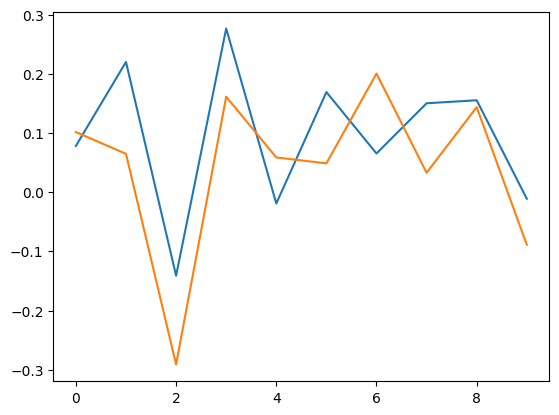

In [46]:
plt.plot(ACC_DJF.values)
plt.plot(ACC_ANN.values)

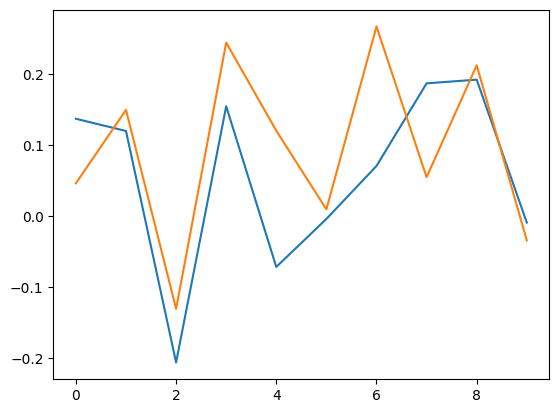

In [14]:
plt.plot(ACC_DJF.values)
plt.plot(ACC_ANN.values)

In [7]:
ds_ERA5_mon

<xarray.Dataset>
Dimensions:      (time: 744)
Coordinates:
    level        (time) int64 dask.array<chunksize=(744,), meta=np.ndarray>
    mode         int64 ...
    month        (time) int64 dask.array<chunksize=(744,), meta=np.ndarray>
  * time         (time) datetime64[ns] 1958-01-01 1958-02-01 ... 2019-12-01
Data variables:
    NAO monthly  (time) float64 dask.array<chunksize=(744,), meta=np.ndarray>

In [9]:
ds_ERA5_mon['time']

<xarray.DataArray 'time' (time: 744)>
array(['1958-01-01T00:00:00.000000000', '1958-02-01T00:00:00.000000000',
       '1958-03-01T00:00:00.000000000', ..., '2019-10-01T00:00:00.000000000',
       '2019-11-01T00:00:00.000000000', '2019-12-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    level    (time) int64 dask.array<chunksize=(744,), meta=np.ndarray>
    mode     int64 ...
    month    (time) int64 dask.array<chunksize=(744,), meta=np.ndarray>
  * time     (time) datetime64[ns] 1958-01-01 1958-02-01 ... 2019-12-01

In [21]:
ds_monthly = nao_monthly.to_dataset(name="NAO monthly")

ds_monthly = ds_monthly.chunk({'time': 744,})
# ds_monthly.to_zarr(save_name)